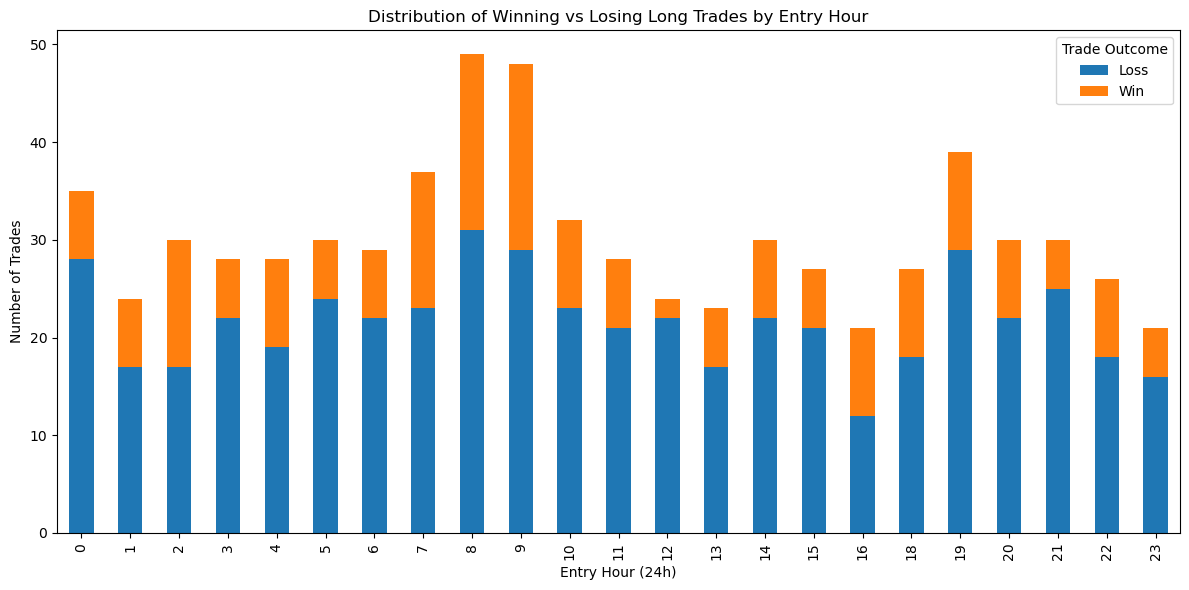

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---
file_path = "testing_1Dec-9Jan.xlsx"
df = pd.read_excel(file_path)

# --- Filter for long entries only ---
df_long = df[df["Type"] == "Entry long"].copy()

# --- Ensure entry time is datetime ---
df_long["entry_time"] = pd.to_datetime(df_long["Date and time"])

# --- Extract hour of day ---
df_long["hour"] = df_long["entry_time"].dt.hour

# --- Classify win vs loss ---
df_long["result"] = df_long["Net P&L USD"].apply(lambda x: "Win" if x > 0 else "Loss")

# --- Aggregate counts by hour and result ---
distribution = (
    df_long
    .groupby(["hour", "result"])
    .size()
    .unstack(fill_value=0)
)

# --- Plot stacked bar chart ---
distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribution of Winning vs Losing Long Trades by Entry Hour")
plt.xlabel("Entry Hour (24h)")
plt.ylabel("Number of Trades")
plt.legend(title="Trade Outcome")
plt.tight_layout()
plt.show()



In [16]:
df_long.head(5)

,Trade #,Type,Date and time,Signal,Price USD,Position size (qty),Position size (value),Net P&L USD,Net P&L %,Favorable excursion USD,Favorable excursion %,Adverse excursion USD,Adverse excursion %,Cumulative P&L USD,Cumulative P&L %,entry_time,hour,result
1,1,Entry long,2025-11-30 19:15,Entry Area,4258.3,2,851660,-720,-0.08,300,0.04,-720,-0.08,-720,-0.07,2025-11-30 19:15:00,19,Loss
3,2,Entry long,2025-11-30 19:47,Entry Area,4265.8,2,853160,-640,-0.08,40,0.00,-640,-0.08,-1360,-0.14,2025-11-30 19:47:00,19,Loss
5,3,Entry long,2025-11-30 20:08,Entry Area,4258.1,2,851620,2300,0.27,2300,0.27,-640,-0.08,940,0.09,2025-11-30 20:08:00,20,Win
7,4,Entry long,2025-11-30 22:15,Entry Area,4267.9,2,853580,1600,0.19,1600,0.19,-120,-0.01,2540,0.25,2025-11-30 22:15:00,22,Win
9,5,Entry long,2025-11-30 23:48,Entry Area,4278.5,2,855700,-620,-0.07,680,0.08,-620,-0.07,1920,0.19,2025-11-30 23:48:00,23,Loss
